### **릿지 (Ridge)**

- 최소제곱 적합식의 수축 패널티라 불리는 항에 L2 패널티를 추가한 것

- parameter
    - `alpha`
        - 기본값 : 1.0
        - 규제의 강도 → 클수록 회귀계수가 작아지고 과대적합을 방지, 다만 과소적합의 위험
    
    - `solver`
        - 기본값 : `auto`
        - 데이터의 크기 / 희소성에 따라 적합한 solver를 선택
        - `cholesky` : 콜레스키 분해, 가장 기본적인 수식, 데이터의 개수가 작거나 중간 정도일 때 사용
        - `svd` : 특이값 분해, 다중공선성이 있는 경우 안정적으로 계산, 데이터의 개수가 작거나 중간 정도일 때 사용
        - `sparse_cg`, `lspr` : 공액 기울기법(0인 데이터를 무시하고 계산), 대규모 데이터 중 희소 데이터
        - `sag` : 확률적 평균 검사 (기존의 기울기만이 아니라 과거 기울기의 평균을 이용하여 가중치 변화), 행의 개수가 열의 개수보다 월등히 많은 경우
        - `saga` : sag의 확장형, 대규모의 희소 데이터가 존재하는 경우, ElasticNet에서 사용
    
    - `tol`
        - 기본값 : 0.001 (1e-03)
        - 수렴의 판단 기준. 작을수록 정밀. 속도 느려질 수 있음
    
    - `max_iter`
        - 기본값 : None
        - 최적화가 될 때까지 최대 반복 횟수
        - 데이터가 크거나 수치가 불안정한 경우에 필요

- 속성
    - `n_iter`
        - solver가 반복한 횟수를 입력
    - `coef_`
        - 회귀 계수 출력 (규제로 인한 가중치의 감소량 때문에 선형 회귀보다는 낮은 값 출력)

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [2]:
# 데이터셋 로드

diabetes = load_diabetes()

In [3]:
df = pd.DataFrame(diabetes['data'], columns= diabetes['feature_names'])
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
# α → 규제의 강도
# 1e-03, 1e-02, 1e-01, 1e+00, 1e+01
# numpy에 logspace() 함수를 이용해서 데이터 생성

alphas = np.logspace(-3, 1, 5)
alphas

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01])

In [5]:
# alpha 값에 따른 회귀 계수를 파악

data = []

for a in alphas:
    # 모델 생성
    ridge = Ridge(alpha = a)
    ridge.fit(diabetes['data'], diabetes['target'])
    # 학습된 모델의 회귀계수를 data 리스트에 추가
    data.append(
        ridge.coef_
    )

data

[array([  -9.54916175, -239.08695779,  520.3693746 ,  323.82274522,
        -712.32215918,  413.37912498,   65.81132269,  167.51300694,
         720.9399241 ,   68.12336029]),
 array([  -7.19753448, -234.54976419,  520.58860098,  320.51713055,
        -380.6071353 ,  150.48467052,  -78.58927534,  130.31252148,
         592.34795865,   71.13484405]),
 array([   1.30870543, -207.19241786,  489.69517109,  301.76405786,
         -83.46603399,  -70.8268319 , -188.67889782,  115.7121356 ,
         443.81291747,   86.7493154 ]),
 array([  29.46611189,  -83.15427636,  306.35268015,  201.62773437,
           5.90961437,  -29.51549508, -152.04028006,  117.3117316 ,
         262.94429001,  111.87895644]),
 array([ 19.81284181,  -0.91842974,  75.41621398,  55.02515953,
         19.92462111,  13.94871542, -47.5538158 ,  48.2594332 ,
         70.14394833,  44.21389238])]

In [6]:
df_ridge = pd.DataFrame(data, index=alphas, columns = df.columns)

df_ridge

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.001,-9.549162,-239.086958,520.369375,323.822745,-712.322159,413.379125,65.811323,167.513007,720.939924,68.123360
0.010,-7.197534,-234.549764,520.588601,320.517131,-380.607135,150.484671,-78.589275,130.312521,592.347959,71.134844
0.100,1.308705,-207.192418,489.695171,301.764058,-83.466034,-70.826832,-188.678898,115.712136,443.812917,86.749315
1.000,29.466112,-83.154276,306.352680,201.627734,5.909614,-29.515495,-152.040280,117.311732,262.944290,111.878956
10.000,19.812842,-0.918430,75.416214,55.025160,19.924621,13.948715,-47.553816,48.259433,70.143948,44.213892


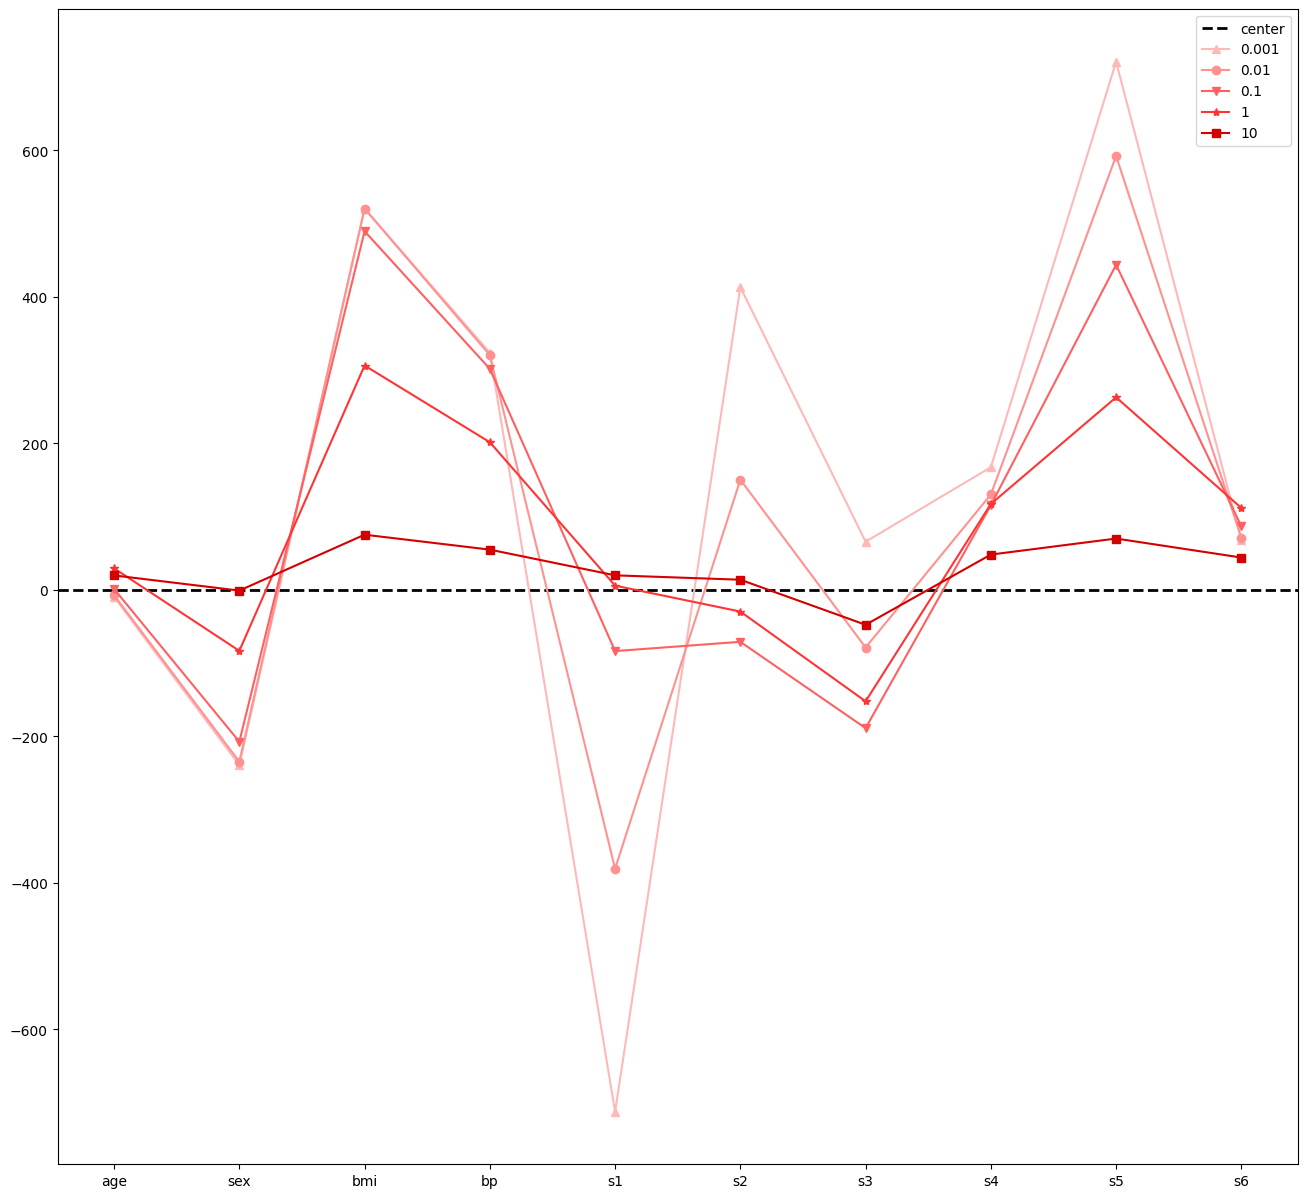

In [17]:
plt.figure(figsize=(16, 15))

plt.axhline(y=0, linestyle='--', linewidth=2, color='black')

plt.plot(df_ridge.loc[0.001, :], '^-', color="#ffb8b8")
plt.plot(df_ridge.loc[0.01, :], 'o-', color="#ff9191")
plt.plot(df_ridge.loc[0.1, :], 'v-', color="#ff6060")
plt.plot(df_ridge.loc[1.0, :], '*-', color="#ff3434")
plt.plot(df_ridge.loc[10.0, :], 's-', color="#d40000")

plt.legend(['center', 0.001, 0.01, 0.1, 1, 10], bbox_to_anchor = (1, 1))
plt.show()

- 연습
    - 당뇨병 데이터를 이용하여 위험 지수 예측
    - train:test = 8:2
    - 선형회귀로 mae 값 확인
    - 릿지에서 알파값 0.01, 0.1, 1 로 mae값 확인

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    diabetes['data'], diabetes['target'], test_size=0.2, random_state=42
    )

In [28]:
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print(round(mean_absolute_error(y_test, pred), 4))
print(round(r2_score(y_test, pred), 4))

42.7941
0.4526


In [30]:
for a in [0.01, 0.1, 1]:
    ridge = Ridge(alpha = a)
    ridge.fit(X_train, y_train)
    pred2 = ridge.predict(X_test)
    print(f'alpha = {a} / MAE = {round(mean_absolute_error(y_test, pred2), 4)} / r² = {round(r2_score(y_test, pred2), 4)}')

alpha = 0.01 / MAE = 42.8369 / r² = 0.456
alpha = 0.1 / MAE = 42.9969 / r² = 0.4609
alpha = 1 / MAE = 46.1389 / r² = 0.4192


In [31]:
# 가중치(회귀계수) * 입력값 + 절편 → 예측값

w_list = lr.coef_

In [32]:
# 입력값 X_test
x_list = X_test[0]

In [33]:
# 절편 값
b = lr.intercept_

In [35]:
b_1 = b

for i in range(len(x_list)):
    b_1 += w_list[i] * x_list[i]

print(b_1, pred[0])

139.54755840379616 139.5475584037962


In [37]:
for w, x in zip(w_list, x_list):
    # print(w)
    # print(x)
    b += w * x

b

np.float64(139.54755840379616)

### 라쏘(Lasso)

- 선형 회귀에서 L1 패널티를 추가한 방법
- parameter
    - `alpha`
        - 기본값 : 1.0
        - 규제의 강도
        - 규제의 강도가 너무 큰 경우에는 많은 컬럼의 회귀 계수가 0이 되어 모델이 단순화(과소적합)
        - 적절한 규제 강도를 사용시 회귀 계수가 0이 되는 컬럼들이 발생하면서 자동적으로 feature select이라는 불필요한 컬럼을 제거하는 부분이 발생
    
    - `selection`
        - 기본값 : `cyclic`
        - 좌표축 경사법의 업데이트 순서
            - `cyclic` : 순차적으로 업데이트
            - `random` : 무작위 선택 업데이트
    
    - `percompute`
        - 기본값 : `auto`
        - 인자값은 bool
        - 그람행렬을 계산하고 메모리에 저장할것인가?
        - feature의 개수가 너무 많다면 False, 개수가 적다면 True
    
    - `warm_start`
        - 기본값 : False
        - 이전의 학습 결과를 기억할것인가?

In [38]:
from sklearn.linear_model import Lasso

In [40]:
x = diabetes['data']
y = diabetes['target']

In [41]:
lasso_1 = Lasso(alpha = 0.01)
lasso_2 = Lasso(alpha = 0.1)
lasso_3 = Lasso(alpha = 1)

In [42]:
lasso_1.fit(X_train, y_train)
lasso_2.fit(X_train, y_train)
lasso_3.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [44]:
pred1 = lasso_1.predict(X_test)
pred2 = lasso_2.predict(X_test)
pred3 = lasso_3.predict(X_test)

In [45]:
print(mean_absolute_error(y_test, pred1))
print(mean_absolute_error(y_test, pred2))
print(mean_absolute_error(y_test, pred3))

42.83184707336087
42.85442771664998
49.73032753662261


In [46]:
print(r2_score(y_test, pred1))
print(r2_score(y_test, pred2))
print(r2_score(y_test, pred3))

0.4566861194580625
0.4718547867276227
0.3575918767219113


In [47]:
from sklearn.preprocessing import PolynomialFeatures

In [48]:
poly = PolynomialFeatures()

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [49]:
lasso_1.fit(X_train_poly, y_train)
lasso_2.fit(X_train_poly, y_train)
lasso_3.fit(X_train_poly, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [50]:
pred_1 = lasso_1.predict(X_test_poly)
pred_2 = lasso_2.predict(X_test_poly)
pred_3 = lasso_3.predict(X_test_poly)

In [51]:
print(r2_score(y_test, pred_1))
print(r2_score(y_test, pred_2))
print(r2_score(y_test, pred_3))

0.49076078413751056
0.4718547867276227
0.3575918767219113


### ElasticNet

- Ridge, Lasso를 절충한 알고리즘
- L1, L2 패널티를 혼합하여 사용 → 매개변수에서 혼합의 비율

- parameter
    - `alpha`
        - 기본값 : 1.0
        - 규제의 강도 (L1, L2 모두 포함)
    
    - `l1_ratio`
        - 기본값 : 0.5
        - L1 패널티의 비중

In [52]:
from sklearn.linear_model import ElasticNet

In [53]:
ela_1 = ElasticNet(alpha=0.01)
ela_2 = ElasticNet(alpha=0.1)
ela_3 = ElasticNet(alpha=1)

ela_1.fit(X_train, y_train)
ela_2.fit(X_train, y_train)
ela_3.fit(X_train, y_train)

pred_1 = ela_1.predict(X_test)
pred_2 = ela_2.predict(X_test)
pred_3 = ela_3.predict(X_test)

print(r2_score(y_test, pred_1))
print(r2_score(y_test, pred_2))
print(r2_score(y_test, pred_3))

0.37364841571505814
0.09865421116113748
-0.0024652131111431164


### 연습문제

- 데이터 수집
    - sklearn 안 샘플 데이터셋 중 fetch_california_housing 데이터셋을 로드
    - 샘플 데이터를 이용하여 독립변수, 종속변수로 데이터를 각각 저장

- 데이터 튜닝
    - 7:3 비율의 학습 데이터와 검증 데이터로 분할

- 선형 회귀 모델과, 엘라스틱넷 모델 생성
    - alpha: 0.01, 0.1, 1
    - l1_ratio: 0, 0.5, 1
    - 반복문을 이용하여 성능평가, 또는 모델의 성능 평가는 함수로 생성하고 반복문
- 각각의 모델들의 R2 Score를 확인

In [ ]:
from sklearn.datasets import fetch_california_housing

cali = fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [58]:
cali_df = pd.DataFrame(data = cali['data'], columns = cali['feature_names'])
cali_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [59]:
X = cali['data']
y = cali['target']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

In [78]:
def linear_elastic(function = 'lr', alpha = None, l1_ratio = None):
    if function == 'lr':
        lr = LinearRegression()
        lr.fit(X_train, y_train)
        pred_lr = lr.predict(X_test)
        return print('linear regression r2 score:', r2_score(y_test, pred_lr))

    elif function == 'ela':
        ela = ElasticNet(alpha = alpha, l1_ratio = l1_ratio)
        ela.fit(X_train, y_train)
        pred_ela = ela.predict(X_test)
        return print(f'alpha: {alpha}, l1_ratio: {l1_ratio}, r2_score: {r2_score(y_test, pred_ela)}')

    else:
        raise KeyError('function 값을 잘못 입력했습니다. 입력 가능한 인자값은 "lr" 또는 "ela" 입니다.')

In [79]:
linear_elastic('lr')
linear_elastic('ela', alpha=0.01, l1_ratio=0)
linear_elastic('ela', alpha=0.01, l1_ratio=0.5)
linear_elastic('ela', alpha=0.01, l1_ratio=1)
linear_elastic('ela', alpha=0.1, l1_ratio=0)
linear_elastic('ela', alpha=0.1, l1_ratio=0.5)
linear_elastic('ela', alpha=0.1, l1_ratio=1)
linear_elastic('ela', alpha=1, l1_ratio=0)
linear_elastic('ela', alpha=1, l1_ratio=0.5)
linear_elastic('ela', alpha=1, l1_ratio=1)

linear regression r2 score: 0.5957702326061662


c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.853e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


alpha: 0.01, l1_ratio: 0, r2_score: 0.5994354203305603
alpha: 0.01, l1_ratio: 0.5, r2_score: 0.5998946604826785
alpha: 0.01, l1_ratio: 1, r2_score: 0.5997745477668093


c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.208e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


alpha: 0.1, l1_ratio: 0, r2_score: 0.59315123651177
alpha: 0.1, l1_ratio: 0.5, r2_score: 0.5755216146456115
alpha: 0.1, l1_ratio: 1, r2_score: 0.545117728367666
alpha: 1, l1_ratio: 0, r2_score: 0.5255223848999995
alpha: 1, l1_ratio: 0.5, r2_score: 0.4237946736165633
alpha: 1, l1_ratio: 1, r2_score: 0.288000383674784


c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.532e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [83]:
# 강사님이 만든 함수

def models(x1, x2, y1, y2):
    # 모델들을 생성
    lr = LinearRegression()

    # 엘라스틱에서 사용되는 변수 목록
    alpha_list = [0.01, 0.1, 1]
    l1_list = [0, 0.5, 1]
    model_names = ['Ridge', 'Elastic', 'Lasso']

    # 각 모델들의 성능을 저장하기 위해 빈 딕셔너리 생성
    result = {}

    # 선형 모델 학습, 예측, 평가
    lr.fit(x1, y1)
    pred_lr = lr.predict(x2)
    r2_lr = r2_score(y2, pred_lr)

    result['Linear'] = r2_lr

    for model, l1 in zip(model_names, l1_list):
        for a in alpha_list:
            ela = ElasticNet(alpha = a, l1_ratio=l1)
            ela.fit(x1, y1)
            pred_ela = ela.predict(x2)
            r2_ela = r2_score(y2, pred_ela)

            result[model+' '+str(a)] = r2_ela
    return result

In [84]:
res = models(X_train, X_test, y_train, y_test)

c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.853e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.208e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th

In [86]:
pd.Series(res)

Linear          0.595770
Ridge 0.01      0.599435
Ridge 0.1       0.593151
Ridge 1         0.525522
Elastic 0.01    0.599895
Elastic 0.1     0.575522
Elastic 1       0.423795
Lasso 0.01      0.599775
Lasso 0.1       0.545118
Lasso 1         0.288000
dtype: float64

In [87]:
# 극단치의 경계값을 구한다. (AveRooms)
q_1, q_3 = np.percentile(cali_df['AveRooms'], [25, 75])
print(q_1, q_3)

4.440716235896959 6.052380952380952


In [88]:
IQR = q_3 - q_1
upper = q_3+1.5*IQR
lower = q_1-1.5*IQR

In [92]:
flag1 = cali_df['AveRooms'] < lower
flag2 = cali_df['AveRooms'] > upper

cali_df.loc[flag1|flag2, ]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
73,0.4999,46.0,1.714286,0.571429,18.0,2.571429,37.81,-122.29
155,8.8793,52.0,8.972868,1.131783,861.0,3.337209,37.81,-122.23
511,13.4990,42.0,8.928358,1.000000,1018.0,3.038806,37.82,-122.22
512,12.2138,52.0,9.210227,1.039773,1001.0,2.843750,37.82,-122.23
514,12.3804,52.0,9.122715,1.033943,1192.0,3.112272,37.82,-122.23
...,...,...,...,...,...,...,...,...
20408,7.7889,26.0,8.730038,1.045627,842.0,3.201521,34.19,-118.88
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69


In [94]:
cali_df['price'] = cali.target
cali_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [95]:
df2 = cali_df.loc[~(flag1|flag2), ]
df2.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20129.000000,20129.000000,20129.000000,20129.000000,20129.000000,20129.000000,20129.000000,20129.000000,20129.000000
mean,3.823653,28.813652,5.238801,1.062244,1437.994535,3.052913,35.623364,-119.581741,2.054875
std,1.791989,12.509678,1.154132,0.112499,1132.123106,9.909145,2.129506,2.000629,1.137022
min,0.499900,1.000000,2.032738,0.333333,3.000000,0.750000,32.540000,-124.350000,0.149990
25%,2.561200,18.000000,4.426656,1.005025,799.000000,2.432727,33.930000,-121.810000,1.194000
50%,3.525000,29.000000,5.197183,1.047170,1176.000000,2.821782,34.250000,-118.490000,1.795000
75%,4.714300,37.000000,5.983759,1.095960,1734.000000,3.286822,37.710000,-118.020000,2.631000
max,15.000100,52.000000,8.469738,3.099338,35682.000000,1243.333333,41.950000,-114.550000,5.000010


In [96]:
X = df2.drop('price', axis=1)
y = df2['price']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [98]:
res = models(X_train, X_test, y_train, y_test)

c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.572e+03, tolerance: 1.820e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.922e+03, tolerance: 1.820e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th

In [99]:
pd.Series(res).sort_values(ascending=False)

Linear          0.600531
Ridge 0.01      0.595370
Elastic 0.01    0.593559
Lasso 0.01      0.589548
Ridge 0.1       0.577523
Elastic 0.1     0.555988
Lasso 0.1       0.516866
Ridge 1         0.499412
Elastic 1       0.392867
Lasso 1         0.243299
dtype: float64

In [100]:
# df2에 스케일링 작업을 한 뒤 모델에서 학습

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
X_train_sc = minmax.fit_transform(X_train, y_train)
X_test_sc = minmax.transform(X_test)
res = models(X_train_sc, X_test_sc, y_train, y_test)
pd.Series(res).sort_values(ascending=False)

c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.901e+03, tolerance: 1.820e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\hkssn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.222e+03, tolerance: 1.820e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th

Linear          0.600531
Lasso 0.01      0.524514
Elastic 0.01    0.492823
Ridge 0.01      0.453164
Ridge 0.1       0.161037
Elastic 0.1     0.100162
Ridge 1         0.022553
Elastic 1      -0.000055
Lasso 0.1      -0.000055
Lasso 1        -0.000055
dtype: float64